**Yu-gi-oh Forecast**

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [113]:
#read from dataset
df = pd.read_csv("yugioh_enriched.csv", usecols=['name', 'type','race','card_sets_set_name','card_sets_set_rarity_code','card_sets_set_price','card_prices_cardmarket_price','card_sets_set_code'])
df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace('(','')
df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace(')','')
df['card_sets_set_rarity_code']= df['card_sets_set_rarity_code'].fillna("C")
df.head(5)

C:\Users\19319\AppData\Local\Temp\ipykernel_12452\3375226365.py:3: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace('(','')
C:\Users\19319\AppData\Local\Temp\ipykernel_12452\3375226365.py:4: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace(')','')


,name,type,race,card_sets_set_name,card_sets_set_code,card_sets_set_rarity_code,card_sets_set_price,card_prices_cardmarket_price
0,Tornado Dragon,XYZ Monster,Wyrm,Battles of Legend: Relentless Revenge,BLRR-EN084,ScR,4.65,0.19
1,Tornado Dragon,XYZ Monster,Wyrm,Duel Devastator,DUDE-EN019,UR,1.58,0.19
2,Tornado Dragon,XYZ Monster,Wyrm,Legendary Duelists: Synchro Storm,LED8-EN055,C,0.96,0.19
3,Tornado Dragon,XYZ Monster,Wyrm,Maximum Crisis,MACR-EN081,ScR,4.49,0.19
4,Exodia the Forbidden One,Effect Monster,Spellcaster,Dark Beginning 1,DB1-EN139,UR,40.10,0.46


In [114]:
#Grouped df price
df_grouped = df.groupby('card_sets_set_rarity_code').sum().sort_values('card_sets_set_price')
df_grouped

,card_sets_set_price,card_prices_cardmarket_price
card_sets_set_rarity_code,,
SFR,13.50,3.48
DUPR,28.71,0.18
UPR,87.42,0.04
PG,116.53,1.14
DRPR,133.02,0.36
MSR,140.67,6.73
GUR,149.43,8.83
GScR,242.58,8.37
UtR,276.63,1.17


In [115]:
#Grouped mean price
df_grouped_mean =df.groupby('card_sets_set_rarity_code').mean().sort_values('card_sets_set_price')
df_grouped_mean

,card_sets_set_price,card_prices_cardmarket_price
card_sets_set_rarity_code,,
C,2.096224,0.065714
DUPR,3.190000,0.020000
SFR,3.375000,0.870000
DRPR,7.390000,0.020000
GUR,7.864737,0.464737
PG,8.963846,0.087692
SR,10.799474,0.057368
GScR,13.476667,0.465000
MSR,15.630000,0.747778


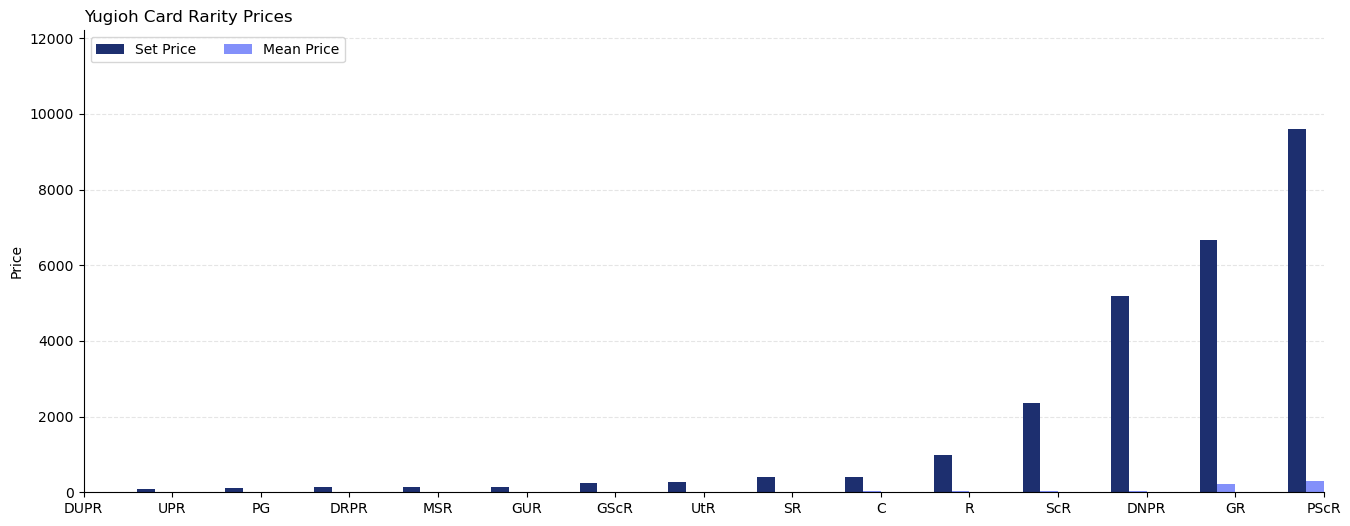

In [116]:
#Plot out average card price by rarity
# define figure
fig, ax = plt.subplots(1, figsize=(16, 6))# numerical x

x = np.arange(0, len(df_grouped.index))# plot bars
plt.bar(x - 0.3, df_grouped['card_sets_set_price'], width = 0.2, color = '#1D2F6F')
plt.bar(x - 0.1, df_grouped_mean['card_sets_set_price'], width = 0.2, color = '#8390FA')

# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# x y details
plt.ylabel('Price')
plt.xticks(x, df_grouped.index)
plt.xlim(1, 15)
# grid lines
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.2)# title and legend
plt.title('Yugioh Card Rarity Prices', loc ='left')
plt.legend(['Set Price','Mean Price'], loc='upper left', ncol = 2)
plt.show()

In [117]:
#Check missing data
df.isnull().values.any()

False

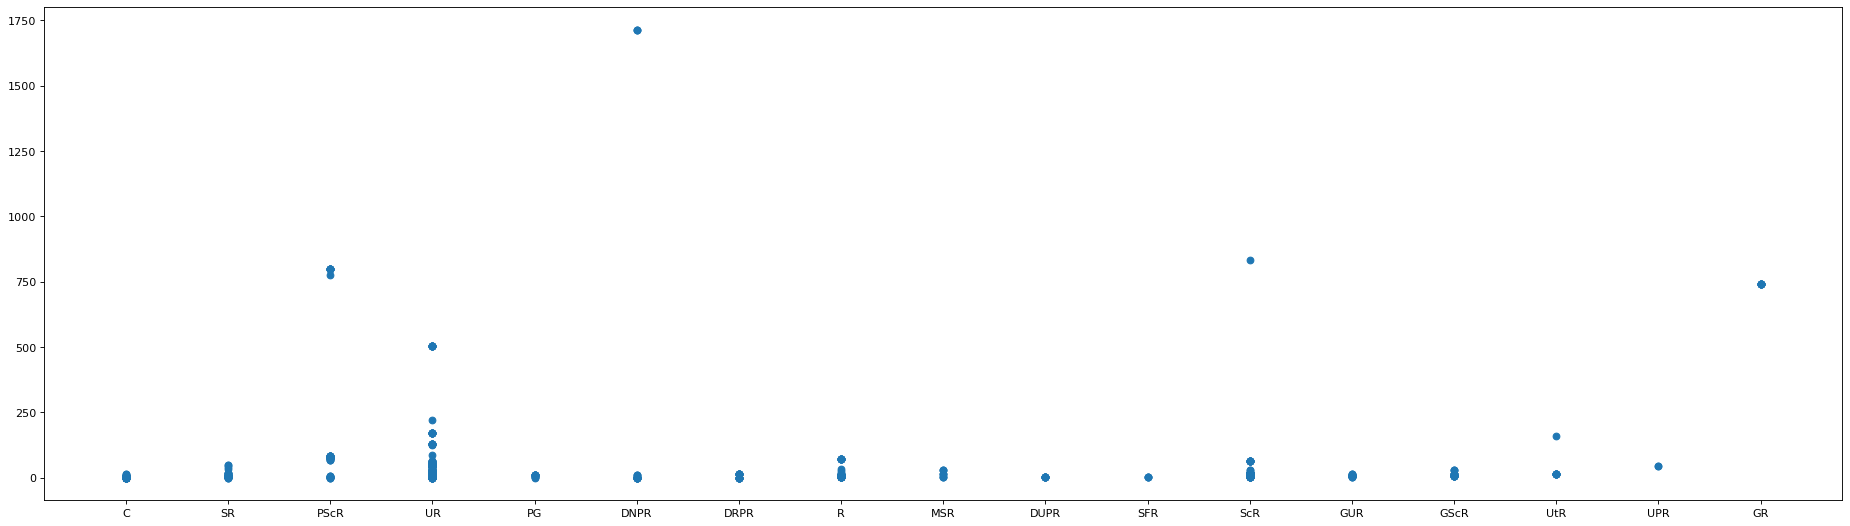

In [119]:
df = df.sort_values('card_sets_set_price')
plt.figure(figsize=(29, 8), dpi=80)
plt.scatter(df['card_sets_set_rarity_code'].astype(str),df['card_sets_set_price'])

In [76]:
df.dtypes

name                             object
type                             object
card_sets_set_name               object
card_sets_set_code               object
card_sets_set_rarity_code        object
card_sets_set_price             float64
card_prices_cardmarket_price    float64
dtype: object

**What is K-Fold cross validation?** 

Cross-validation is a statistical method used to estimate the skill of machine learning models.
That k-fold cross validation is a procedure used to estimate the skill of the model on new data.
There are common tactics that you can use to select the value of k for your dataset.
There are commonly used variations on cross-validation such as stratified and repeated that are available in scikit-learn

Coefficients: 
 [[-39.52214266]]
Mean squared error: 2490.07
Coefficient of determination: -28310.76


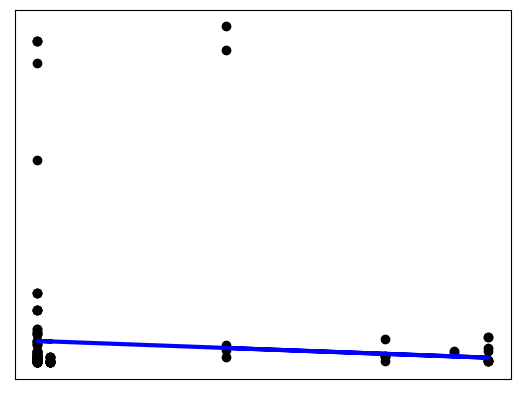

Coefficients: 
 [[-35.70726092]]
Mean squared error: 2944.93
Coefficient of determination: -28935.25


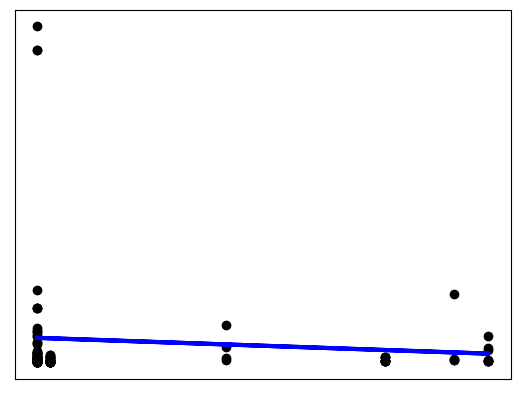

Coefficients: 
 [[-23.57377292]]
Mean squared error: 2094.97
Coefficient of determination: -18400.74


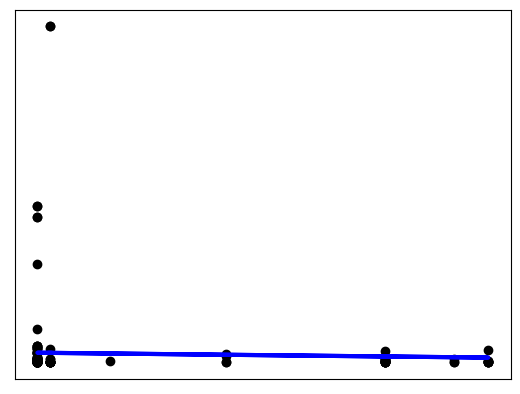

Coefficients: 
 [[-27.32957366]]
Mean squared error: 2311.14
Coefficient of determination: -19918.37


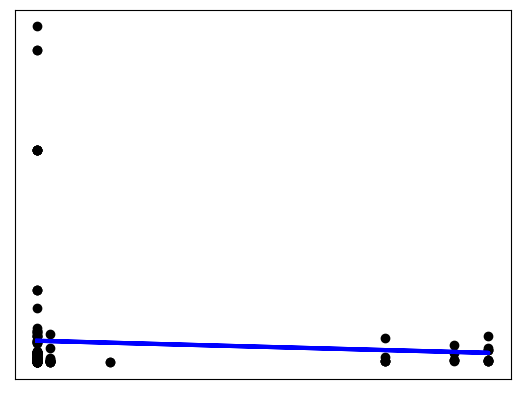

Coefficients: 
 [[-29.37691862]]
Mean squared error: 2381.27
Coefficient of determination: -24209.11


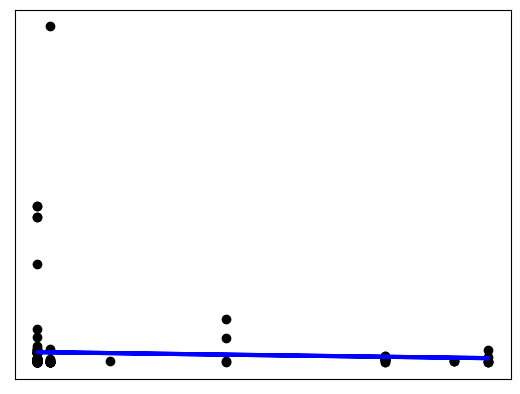

[-0.009512270915846166, -0.05472266542768556, 0.0018045787203762043, 0.009168134013711637, 0.0041022027927922755]


In [215]:
#Identify measure values for predictions
X = pd.DataFrame(df['card_prices_cardmarket_price']).dropna()
y = pd.DataFrame(df['card_sets_set_price'])

model = LinearRegression()
scores = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train, test) in enumerate(kfold.split(X, y)):
    model.fit(X.iloc[train,:], y.iloc[train,:])
    score = model.score(X.iloc[test,:], y.iloc[test,:])
    x_pred=model.predict(X.iloc[test,:])
    scores.append(score)
    
    # The coefficients
    print("Coefficients: \n", model.coef_)
    # The mean squared error
    print("Mean squared error: %.2f" % mean_squared_error(X.iloc[test,:], x_pred))
    # The coefficient of determination: 1 is perfect prediction
    print("Coefficient of determination: %.2f" % r2_score(X.iloc[test,:], x_pred))

    # Plot outputs
    plt.scatter(X.iloc[test,:], y.iloc[test,:], color="black")
    plt.plot(X.iloc[test,:], x_pred, color="blue", linewidth=3)

    plt.xticks(())
    plt.yticks(())

    plt.show()
    
    #Check average score of fold
    t.mean()


print(scores)

In [216]:
#Generate random values
random_number_list=[]
for i in enumerate(range(0, len(X))):
    random_number = random.randrange(0, 10000)
    random_number_list.append(random_number)

In [217]:
#remove random variables to shorten the amount of data being read. Scale the model
X['Random']=random_number_list

# drop_first = True removes multi-collinearity
add_var = pd.get_dummies(X['Random'], prefix='Random', drop_first=True)
# Add all the columns to the model data
X = X.join(add_var)
# Drop the original column that was expanded
X.drop(columns=['Random'], inplace=True)
print(X.head())

     card_prices_cardmarket_price  Random_15  Random_16  Random_27  Random_35  \
669                          0.05          0          0          0          0   
552                          0.05          0          0          0          0   
582                          0.05          0          0          0          0   
584                          0.05          0          0          0          0   
16                           0.46          0          0          0          0   

     Random_45  Random_52  Random_54  Random_60  Random_89  ...  Random_9859  \
669          0          0          0          0          0  ...            0   
552          0          0          0          0          0  ...            0   
582          0          0          0          0          0  ...            0   
584          0          0          0          0          0  ...            0   
16           0          0          0          0          0  ...            0   

     Random_9902  Random_9906  R

In [218]:
#Drop out random fields to align the shape of the df
y['Random']=random_number_list

# drop_first = True removes multi-collinearity
add_var = pd.get_dummies(y['Random'], prefix='Random', drop_first=True)
# Add all the columns to the model data
y = y.join(add_var)
# Drop the original column that was expanded
y.drop(columns=['Random'], inplace=True)
print(X.head())

     card_prices_cardmarket_price  Random_15  Random_16  Random_27  Random_35  \
669                          0.05          0          0          0          0   
552                          0.05          0          0          0          0   
582                          0.05          0          0          0          0   
584                          0.05          0          0          0          0   
16                           0.46          0          0          0          0   

     Random_45  Random_52  Random_54  Random_60  Random_89  ...  Random_9859  \
669          0          0          0          0          0  ...            0   
552          0          0          0          0          0  ...            0   
582          0          0          0          0          0  ...            0   
584          0          0          0          0          0  ...            0   
16           0          0          0          0          0  ...            0   

     Random_9902  Random_9906  R

In [233]:
scores = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train, test) in enumerate(kfold.split(X, y)):
    model.fit(X.iloc[train,:], y.iloc[train,:])
    score = model.score(X.iloc[test,:], y.iloc[test,:])
    x_pred=model.predict(X.iloc[test,:])
    #set prediction as a positive value
    scores.append(score)
    
    # The coefficients
    print("Coefficients: \n", model.coef_)
    # The mean squared error
    print("Mean squared error: %.2f" % mean_squared_error(X.iloc[test,:], x_pred))
    # The coefficient of determination: 1 is perfect prediction
    print("Coefficient of determination: %.2f" % r2_score(X.iloc[test,:], x_pred))
    

    # Plot outputs
    plt.scatter(X.iloc[test,:], y.iloc[test,:], color="black")
    plt.plot( X.iloc[test,:],x_pred, color="blue", linewidth=3)

    plt.xticks(())
    plt.yticks(())

    plt.show()
    
    #Check average score of fold
    print(X.iloc[test,:])
    print(x_pred)
    t.mean()

#Fold Scores
print(scores)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [214]:
#The model is not a good fit needs more data